In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense
from tensorflow.keras.callbacks import Callback
import matplotlib.pyplot as plt
from tensorflow.keras import layers

In [3]:
text_data = [
 "artificial intelligence systems learn patterns from data.",
 "sequence models process information step by step.",
 "recurrent neural networks are useful for sequence prediction.",
 "lstm networks handle long term dependencies.",
 "deep learning models improve sequence learning.",
 "generative models create new samples from learned patterns.",
 "language models predict the next word in a sentence.",
 "sequence generation is used in chatbots and assistants.",
 "machine learning helps computers learn automatically.",
 "training data improves model accuracy.",
 "neural networks simulate human brain structures.",
 "optimization algorithms improve learning efficiency.",
 "technology is transforming modern education.",
 "online learning platforms use artificial intelligence.",
 "students benefit from intelligent tutoring systems.",
 "automation improves productivity and decision making."
]

In [4]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(text_data)

total_words = len(tokenizer.word_index) + 1
index_to_word = tokenizer.index_word

input_sequences = []

for line in text_data:
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_sequence_len = max(len(seq) for seq in input_sequences)

input_sequences = pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre')

X, y = input_sequences[:, :-1], input_sequences[:, -1]
y = tf.keras.utils.to_categorical(y, num_classes=total_words)

LSTM

In [5]:
model_lstm = Sequential([
    Input(shape=(max_sequence_len-1,)),
    Embedding(total_words, 64),
    LSTM(150),
    Dense(total_words, activation='softmax')
])

model_lstm.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 8, 64)          │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 150)            │       129,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 78)             │        11,778 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 145,770 (569.41 KB)

 Trainable params: 145,770 (569.41 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
class PrintEveryNEpochs(Callback):
    def __init__(self, interval=20):
        self.interval = interval

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.interval == 0:
            print(f"Epoch {epoch+1}: Loss={logs['loss']:.4f}, Acc={logs['accuracy']:.4f}")

history_lstm = model_lstm.fit(
    X, y,
    epochs=100,
    verbose=0,
    callbacks=[PrintEveryNEpochs(20)]
)

Epoch 20: Loss=3.7204, Acc=0.1250
Epoch 40: Loss=2.2084, Acc=0.5341
Epoch 60: Loss=1.1747, Acc=0.8295
Epoch 80: Loss=0.6868, Acc=0.9432
Epoch 100: Loss=0.4242, Acc=0.9545


In [7]:
def generate_sequence(seed_text, next_words, model):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')

        predicted = model.predict(token_list, verbose=0)
        predicted_word = index_to_word[np.argmax(predicted)]

        seed_text += " " + predicted_word

    return seed_text

In [8]:
print("\n--- LSTM Output ---")
seed = "artificial intelligence"
print(generate_sequence(seed, 5, model_lstm))


--- LSTM Output ---
artificial intelligence systems learn patterns from data


Transformer


In [9]:
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(vocab_size, embed_dim)
        self.pos_emb = layers.Embedding(maxlen, embed_dim)

    def call(self, x):
        positions = tf.range(start=0, limit=tf.shape(x)[-1], delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions


class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim)
        ])
        self.norm1 = layers.LayerNormalization()
        self.norm2 = layers.LayerNormalization()

    def call(self, x):
        attn = self.att(x, x)
        x = self.norm1(x + attn)
        ffn = self.ffn(x)
        return self.norm2(x + ffn)

In [10]:
embed_dim = 64
num_heads = 2
ff_dim = 128

inputs = layers.Input(shape=(max_sequence_len-1,))
x = TokenAndPositionEmbedding(max_sequence_len-1, total_words, embed_dim)(inputs)
x = TransformerBlock(embed_dim, num_heads, ff_dim)(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(64, activation="relu")(x)
outputs = layers.Dense(total_words, activation="softmax")(x)

model_transformer = tf.keras.Model(inputs, outputs)

model_transformer.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

model_transformer.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding    │ (None, 8, 64)          │         5,504 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 8, 64)          │        50,048 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 78)             │         5,070 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,782 (253.05 KB)

 Trainable params: 64,782 (253.05 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history_transformer = model_transformer.fit(
    X, y,
    epochs=100,
    verbose=0,
    callbacks=[PrintEveryNEpochs(20)]
)

Epoch 20: Loss=2.9464, Acc=0.3409
Epoch 40: Loss=0.8432, Acc=0.9432
Epoch 60: Loss=0.1272, Acc=0.9886
Epoch 80: Loss=0.0538, Acc=0.9886
Epoch 100: Loss=0.0362, Acc=0.9886



--- Transformer Output ---
generative models create new samples from learned


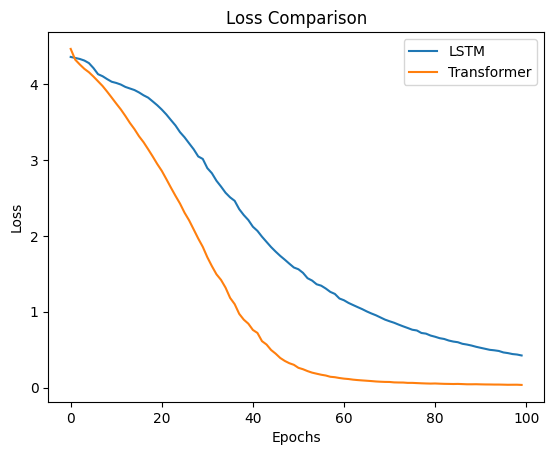

In [12]:
print("\n--- Transformer Output ---")
seed = "generative models"
print(generate_sequence(seed, 5, model_transformer))

plt.plot(history_lstm.history['loss'], label='LSTM')
plt.plot(history_transformer.history['loss'], label='Transformer')
plt.legend()
plt.title("Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()